In [1]:
import pandas as pd
import geopandas as gpd


df = pd.read_csv(r"data/result1/cities_minute_counts.csv")

df["create_time"] = pd.to_datetime(df["create_time"])

gdf = gpd.read_file(r"data/result2/cities.shp")


C:\Users\Admin\AppData\Local\Temp\ipykernel_35688\3173606452.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  npi_df = df_sub.groupby('city').apply(calc_npi).reset_index(name=label)
C:\Users\Admin\AppData\Local\Temp\ipykernel_35688\3173606452.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  npi_df = df_sub.groupby('city').apply(calc_npi).reset_index(name=label)
C:\Users\Admin\AppData\Local\Temp\ipykernel_3568

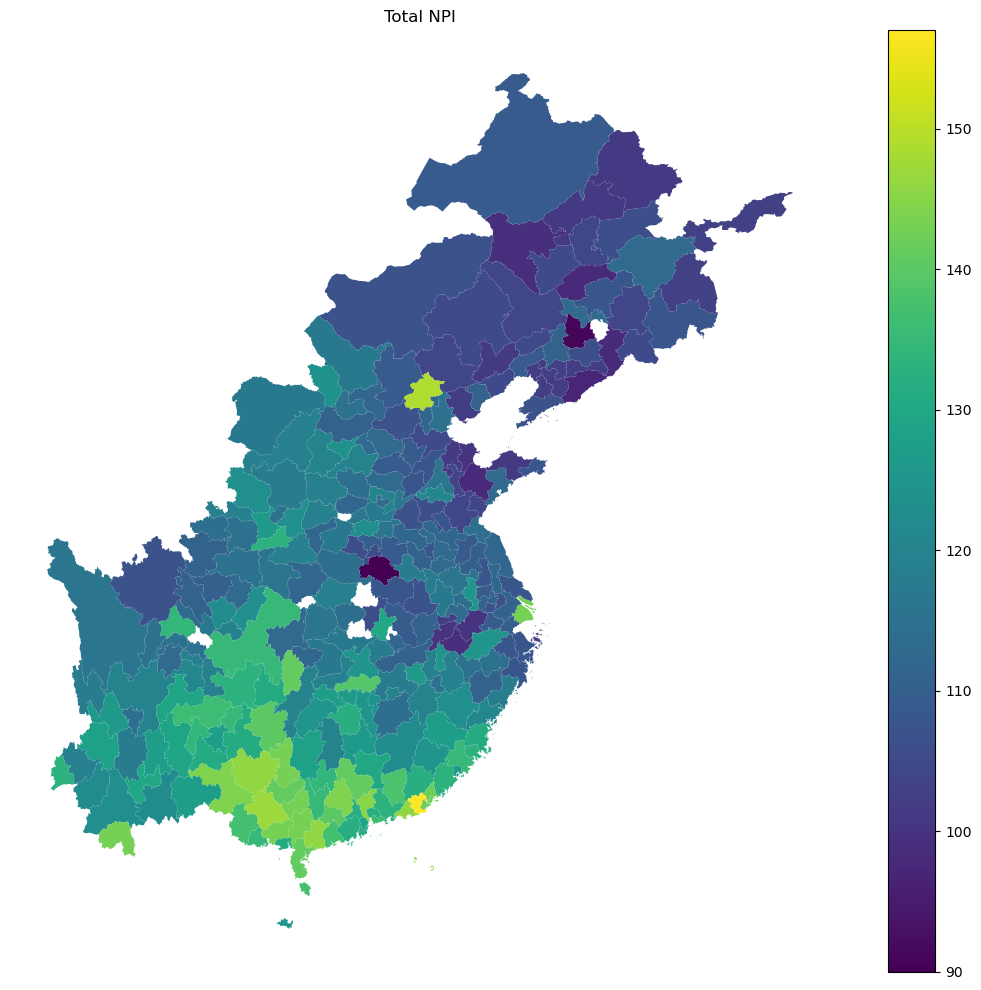

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df['month'] = df['create_time'].dt.month
df['dayofweek'] = df['create_time'].dt.dayofweek

conditions = {
    'Total': pd.Series(True, index=df.index),
    'Spring': df['month'].isin([3, 4, 5]),
    'Summer': df['month'].isin([6, 7, 8]),
    'Autumn': df['month'].isin([9, 10, 11]),
    'Winter': df['month'].isin([12, 1, 2]),
    'Weekday': df['dayofweek'].isin([0, 1, 2, 3, 4]),
    'Weekend': df['dayofweek'].isin([5, 6])
}

def calc_npi(group):
    # Aggregated post counts per time bin instead of counting rows
    ts = group.groupby('time_bin')['post_count'].sum()
    if ts.empty:
        return np.nan
    
    ts_sorted = ts.sort_index().reindex(range(0, int(ts.index.max()) + 1), fill_value=0)
    S = ts_sorted.cumsum().astype(float)
    S_total = S.iloc[-1]
    
    if S_total == 0:
        return np.nan
        
    one_minus_f = 1 - (S / S_total)
    mask_50 = one_minus_f <= 0.5
    
    if mask_50.any():
        return mask_50.idxmax()
    return np.nan

results = []

for label, cond_mask in conditions.items():
    df_sub = df[cond_mask & ((df['create_time'].dt.hour >= 21) | (df['create_time'].dt.hour < 4))].copy()
    
    df_sub['time_bin'] = df_sub['create_time'].apply(
        lambda dt: (dt.hour - 21) * 60 + dt.minute if dt.hour >= 21 else 180 + dt.hour * 60 + dt.minute
    )
    
    npi_df = df_sub.groupby('city').apply(calc_npi).reset_index(name=label)
    results.append(npi_df)

final_npi_df = results[0]
for res in results[1:]:
    final_npi_df = final_npi_df.merge(res, on='city', how='outer')

gdf_plot = gdf.merge(final_npi_df, left_on='city', right_on='city', how='left')

fig, ax = plt.subplots(figsize=(12, 10))
gdf_plot.plot(
    column='Total',
    cmap='viridis',
    legend=True,
    ax=ax,
    missing_kwds={'color': '#eeeeee'}
)
ax.set_title('Total NPI')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [3]:
gdf_plot

,city,geometry,Total,Spring,Summer,Autumn,Winter,Weekday,Weekend
0,梅州,"POLYGON Z ((115.88406 24.92896 0, 115.89031 24...",132,132,136,132,128,132,131
1,吕梁,"POLYGON Z ((111.20539 38.72164 0, 111.20739 38...",120,113,120,120,120,120,120
2,舟山,"MULTIPOLYGON Z (((122.25205 29.69094 0, 122.23...",102,99,105,101,103,103,101
3,朝阳,"POLYGON Z ((119.6002 42.27468 0, 119.60812 42....",101,99,102,100,101,100,105
4,广安,"MULTIPOLYGON Z (((107.26394 30.38628 0, 107.27...",119,113,119,115,123,118,119
...,...,...,...,...,...,...,...,...,...
271,陇南,"POLYGON Z ((105.24292 34.52701 0, 105.2453 34....",111,108,110,107,122,111,111
272,保山,"POLYGON Z ((98.7239 25.82049 0, 98.7109 25.806...",119,116,123,116,120,119,118
273,遂宁,"MULTIPOLYGON Z (((105.90684 30.48512 0, 105.91...",117,115,118,115,123,118,117
274,合肥,"POLYGON Z ((117.19746 32.52641 0, 117.20584 32...",117,112,121,118,115,114,121


=== ANOVA Results for Seasons ===
                   F        PR(>F)    eta_sq
C(Season)  14.690181  2.199061e-09  0.038521

=== ANOVA Results for Week Types ===
                    F    PR(>F)    eta_sq
C(Day_Type)  3.701402  0.054883  0.006685


C:\Users\Admin\AppData\Local\Temp\ipykernel_35688\2622026708.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


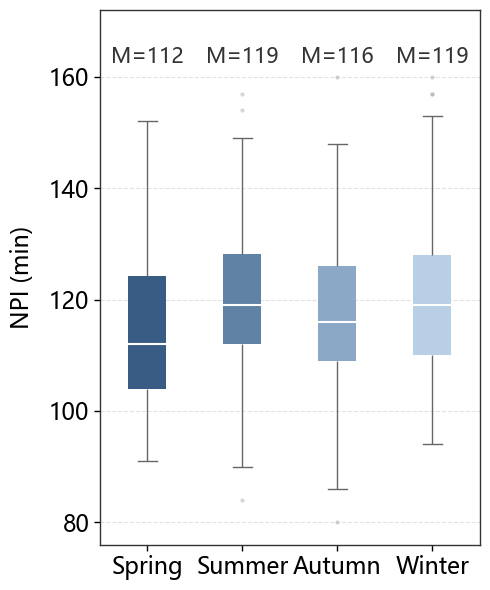

C:\Users\Admin\AppData\Local\Temp\ipykernel_35688\2622026708.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


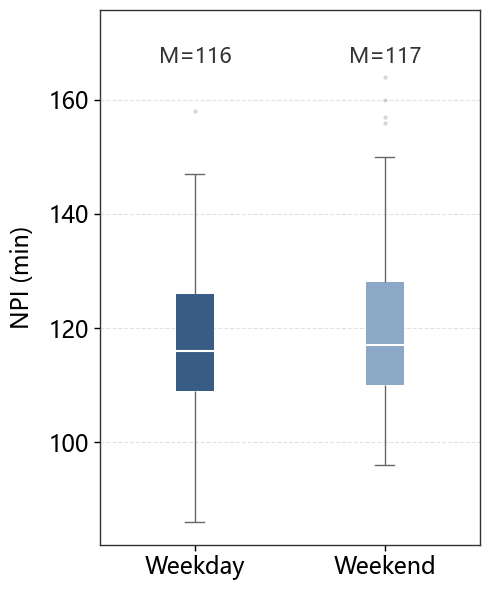

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
week_types = ['Weekday', 'Weekend']

df_seasons = []
for season in seasons:
    temp_df = final_npi_df[['city', f'{season}']].dropna().copy()
    temp_df['Season'] = season
    temp_df.rename(columns={f'{season}': 'NPI'}, inplace=True)
    df_seasons.append(temp_df)
df_seasons = pd.concat(df_seasons, ignore_index=True)

df_weeks = []
for wt in week_types:
    temp_df = final_npi_df[['city', f'{wt}']].dropna().copy()
    temp_df['Day_Type'] = wt
    temp_df.rename(columns={f'{wt}': 'NPI'}, inplace=True)
    df_weeks.append(temp_df)
df_weeks = pd.concat(df_weeks, ignore_index=True)

print("=== ANOVA Results for Seasons ===")
model_seasons = ols('NPI ~ C(Season)', data=df_seasons).fit()
anova_seasons = sm.stats.anova_lm(model_seasons, typ=2)
anova_seasons['eta_sq'] = anova_seasons['sum_sq'] / sum(anova_seasons['sum_sq'])
print(anova_seasons[['F', 'PR(>F)', 'eta_sq']].dropna())

print("\n=== ANOVA Results for Week Types ===")
model_weeks = ols('NPI ~ C(Day_Type)', data=df_weeks).fit()
anova_weeks = sm.stats.anova_lm(model_weeks, typ=2)
anova_weeks['eta_sq'] = anova_weeks['sum_sq'] / sum(anova_weeks['sum_sq'])
print(anova_weeks[['F', 'PR(>F)', 'eta_sq']].dropna())
print("=" * 34)

plt.style.use('default')

palette_seasons = {
    'Spring': '#2b5c8f',
    'Summer': '#5582b0',
    'Autumn': '#82a8d1',
    'Winter': '#b0cfee'
}

palette_weeks = {
    'Weekday': '#2b5c8f',
    'Weekend': '#82a8d1'
}

plot_configs = [
    {
        'df': df_seasons, 'x_col': 'Season', 'order': seasons, 
        'palette': palette_seasons, 'save_name': r'NPI_Season.jpg'
    },
    {
        'df': df_weeks, 'x_col': 'Day_Type', 'order': week_types, 
        'palette': palette_weeks, 'save_name': r'NPI_boxplot_Weekday_Weekend.jpg'
    }
]

plt.rcParams['font.sans-serif'] = ['Microsoft Yahei', 'SimHei', 'Arial']

for config in plot_configs:
    df = config['df']
    x_col = config['x_col']
    order = config['order']
    palette = config['palette']
    
    fig, ax = plt.subplots(figsize=(5, 6))
    fixed_width = 0.1 * len(order)
    
    sns.boxplot(
        data=df, x=x_col, y='NPI', order=order,
        ax=ax, palette=palette,
        width=fixed_width, 
        linewidth=1.0,
        flierprops={
            "marker": "o", 
            "markerfacecolor": "#999999",
            "markersize": 3, 
            "alpha": 0.4, 
            "markeredgecolor": "none"
        },
        boxprops={"edgecolor": "none"},
        medianprops={"color": "white", "linewidth": 1.5},
        whiskerprops={"color": "#666666", "linewidth": 1.0},
        capprops={"color": "#666666", "linewidth": 1.0}
    )
    
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='#e2e2e2', linewidth=0.8)
    ax.xaxis.grid(False)
    
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1)

    y_max_data = df['NPI'].max()
    y_min_data = df['NPI'].min()
    y_range = y_max_data - y_min_data
    
    ax.set_ylim(y_min_data - y_range * 0.05, y_max_data + y_range * 0.15)
    
    text_y_pos = y_max_data + y_range * 0.02
    
    for i, category in enumerate(order):
        cat_data = df[df[x_col] == category]['NPI'].dropna()
        if not cat_data.empty:
            median_val = cat_data.median()
            stat_text = f"M={median_val:.0f}"
            
            ax.text(i, text_y_pos, stat_text, ha='center', va='bottom', 
                    color='#333333', fontsize=15, fontweight='normal')

    ax.set_xlabel("", fontsize=14, labelpad=10)
    ax.set_ylabel("NPI (min)", fontsize=16.5, labelpad=10)
    ax.tick_params(axis='both', labelsize=16.5, width=1, length=4, colors="#000000")

    plt.tight_layout()
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10760\3999207561.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


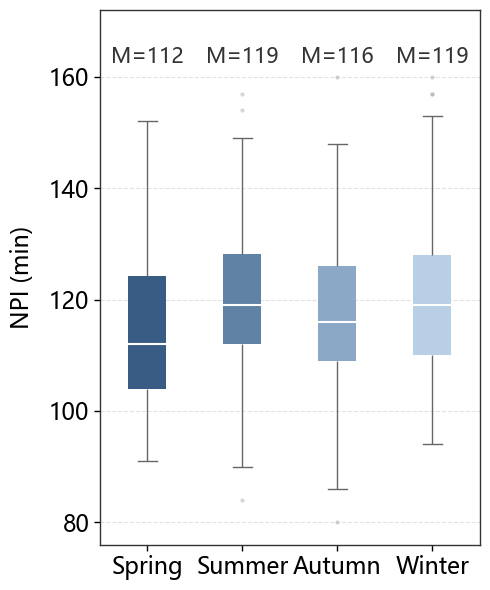

C:\Users\Admin\AppData\Local\Temp\ipykernel_10760\3999207561.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


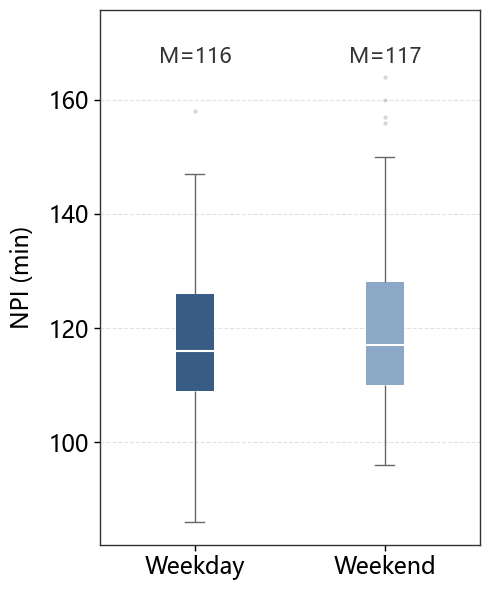

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
week_types = ['Weekday', 'Weekend']

# Prepare data for seasons
df_seasons = []
for season in seasons:
    temp_df = final_npi_df[['city', f'{season}']].dropna().copy()
    temp_df['Season'] = season
    temp_df.rename(columns={f'{season}': 'NPI'}, inplace=True)
    df_seasons.append(temp_df)
df_seasons = pd.concat(df_seasons, ignore_index=True)

# Prepare data for week types
df_weeks = []
for wt in week_types:
    temp_df = final_npi_df[['city', f'{wt}']].dropna().copy()
    temp_df['Day_Type'] = wt
    temp_df.rename(columns={f'{wt}': 'NPI'}, inplace=True)
    df_weeks.append(temp_df)
df_weeks = pd.concat(df_weeks, ignore_index=True)

# Plotting configuration
plt.style.use('default')

# ==================== 1. 重新定义更高级的配色 ====================
# 低饱和度、学术顶刊风格的莫兰迪色系
# ==================== 渐变色方案配置 ====================

# 方案 A：高级学术蓝（由深到浅的同色系渐变，极具现代感）
palette_seasons = {
    'Spring': '#2b5c8f',  # 深蓝
    'Summer': '#5582b0',  # 中蓝
    'Autumn': '#82a8d1',  # 浅蓝
    'Winter': '#b0cfee'   # 极浅蓝
}

# 或者 方案 B：季节温度渐变（冷感 -> 暖感）
# palette_seasons = {
#     'Spring': '#74a9cf',  # 柔蓝
#     'Summer': '#3690c0',  # 翠蓝
#     'Autumn': '#fec44f',  # 暖黄
#     'Winter': '#d7301f'   # 砖红（低饱和度）
# }

# 工作日 vs 周末：使用同色系的一深一浅，干净利落
palette_weeks = {
    'Weekday': '#2b5c8f', # 深蓝色（代表工作日的沉稳）
    'Weekend': '#82a8d1'  # 浅蓝色（代表周末的放松）
}

plot_configs = [
    {
        'df': df_seasons, 'x_col': 'Season', 'order': seasons, 
        'palette': palette_seasons, 'save_name': r'NPI_Season.jpg'
    },
    {
        'df': df_weeks, 'x_col': 'Day_Type', 'order': week_types, 
        'palette': palette_weeks, 'save_name': r'NPI_boxplot_Weekday_Weekend.jpg'
    }
]

# ==================== 2. 优化后的画图循环 ====================
plt.rcParams['font.sans-serif'] = ['Microsoft Yahei', 'SimHei', 'Arial'] # 确保英文和符号不崩

for config in plot_configs:
    df = config['df']
    x_col = config['x_col']
    order = config['order']
    palette = config['palette']
    
    # 调整画布比例，让它稍微矮宽一点 (5宽, 5.5高)，避免过度纵向拉伸
    fig, ax = plt.subplots(figsize=(5, 6))
    fixed_width = 0.1 * len(order)
    # 【优化】固定箱体宽度 0.5-0.6，彻底解决箱体变成“细线”或“电线杆”的问题
    sns.boxplot(
        data=df, x=x_col, y='NPI', order=order,
        ax=ax, palette=palette,
        width=fixed_width, 
        linewidth=1.0,  # 【优化】线条改细，告别粗笨感
        flierprops={
            "marker": "o", 
            "markerfacecolor": "#999999", # 异常值颜色稍微加深一点
            "markersize": 3, 
            "alpha": 0.4, 
            "markeredgecolor": "none"
        },
        boxprops={"edgecolor": "none"},       # 【优化】纯黑框改为精致的深灰框
        medianprops={"color": "white", "linewidth": 1.5}, # 中位数线稍微突出
        whiskerprops={"color": "#666666", "linewidth": 1.0},
        capprops={"color": "#666666", "linewidth": 1.0}
    )
    
    # 【优化】极淡的网格线，绝对不抢主体戏份
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='#e2e2e2', linewidth=0.8)
    ax.xaxis.grid(False)
    
    # 边框颜色同步改为深灰
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1)

    # 计算数据范围
    y_max_data = df['NPI'].max()
    y_min_data = df['NPI'].min()
    y_range = y_max_data - y_min_data
    
    # 【优化】重新设计 Y 轴边界：下方留白 5%，上方留白 15% 给文字留出“呼吸空间”
    ax.set_ylim(y_min_data - y_range * 0.05, y_max_data + y_range * 0.15)
    
    # 【优化】让 M=xxx 文字统一飘在图表顶端，不和箱线图的触须（Whisker）打架
    text_y_pos = y_max_data + y_range * 0.02
    
    for i, category in enumerate(order):
        cat_data = df[df[x_col] == category]['NPI'].dropna()
        if not cat_data.empty:
            median_val = cat_data.median()
            stat_text = f"M={median_val:.0f}"
            
            # 使用常规字重 (regular/normal)，避免加粗显得笨重
            ax.text(i, text_y_pos, stat_text, ha='center', va='bottom', 
                    color='#333333', fontsize=15, fontweight='normal')

    # 轴标签优化
    ax.set_xlabel("", fontsize=14, labelpad=10)
    ax.set_ylabel("NPI (min)", fontsize=16.5, labelpad=10)
    ax.tick_params(axis='both', labelsize=16.5, width=1, length=4, colors="#000000")

    plt.tight_layout()
    plt.savefig(config['save_name'], dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
gdf_plot.to_file(r'../map/NPI_season.shp')

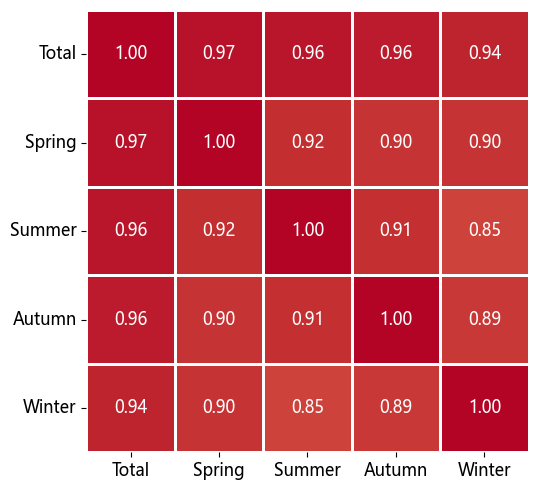

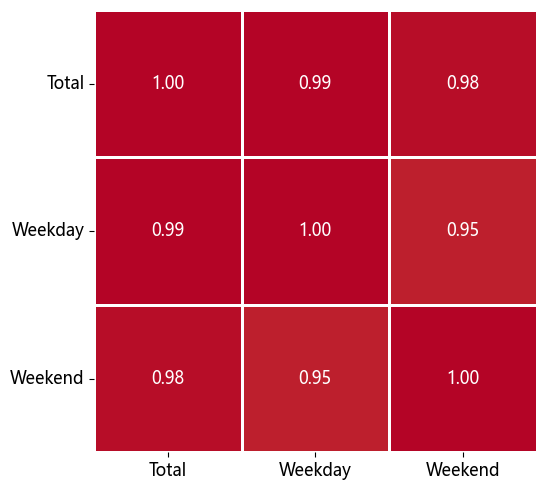

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

cols_season = ['Total', 'Spring', 'Summer', 'Autumn', 'Winter', ]
cols_week = ['Total', 'Weekday', 'Weekend', ]


def plot_corr_heatmap(cols, title, figsize, i):
    plt.figure(figsize=figsize)
    corr = final_npi_df[cols].corr()
    

    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                square=True, linewidths=1, cbar=False,
                annot_kws={"size": 12})
    
    plt.title(title, fontsize=14, pad=15)
    plt.xticks(fontsize=12, rotation=0 )
    plt.yticks(fontsize=12, rotation=0)
    plt.tight_layout()
    # if i == 0:
    #     plt.savefig(r'season_corr.jpg', dpi=300, bbox_inches='tight')
    # elif i == 1:
    #     plt.savefig(r'week_corr.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

plot_corr_heatmap(cols_season, "", (6, 5), 0)

plot_corr_heatmap(cols_week, "", (6, 5), 1)